In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    count = 0
    for filename in filenames:
        if dirname == "/kaggle/input/yahoo-qa-preprocessed" and count == 0:
            print()
            count += 1
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/artifacts/skipgram_word2vec.model.syn1neg.npy
/kaggle/input/artifacts/skipgram_embedding_matrix.npy
/kaggle/input/artifacts/glove_embedding_matrix.npy
/kaggle/input/artifacts/skipgram_word2vec.model.wv.vectors.npy
/kaggle/input/artifacts/tokenizer.pkl
/kaggle/input/artifacts/skipgram_word2vec.model

/kaggle/input/yahoo-qa-preprocessed/uptaded_train_preprocessed.csv
/kaggle/input/yahoo-qa-preprocessed/uptaded_test_preprocessed.csv


# Imports

In [35]:
import os
import joblib


import numpy as np
import pandas as pd

import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, SimpleRNN, Bidirectional, Dense, Dropout

# NN Models with Embeddings

## 1. Load preprocessed CSVs

In [27]:
train_df = pd.read_csv("/kaggle/input/yahoo-qa-preprocessed/uptaded_train_preprocessed.csv")
test_df  = pd.read_csv("/kaggle/input/yahoo-qa-preprocessed/uptaded_test_preprocessed.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (280003, 29)
Test shape: (59999, 29)


## 2. Load tokenizer

In [28]:
with open("/kaggle/input/artifacts/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

## 4. Encode labels

In [32]:
train_texts = train_df["clean_text_basic"].astype(str).tolist()
test_texts  = test_df["clean_text_basic"].astype(str).tolist()

# Labels
y_train = train_df["Class"].values
y_test  = test_df["Class"].values

# Encode labels to integers
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test  = label_encoder.transform(y_test)

# Save encoder
os.makedirs("dump_artifacts", exist_ok=True)

# Save label encoder
joblib.dump(label_encoder, "dump_artifacts/label_encoder.pkl")

['dump_artifacts/label_encoder.pkl']

## 4. Convert Text to Sequences and Add Padding

In [33]:
MAX_LEN = 200

X_train = tokenizer.texts_to_sequences(train_texts)
X_test  = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test  = pad_sequences(X_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", len(y_train), "y_test:", len(y_test))



X_train: (280003, 200) X_test: (59999, 200) y_train: 280003 y_test: 59999


## 5. Train/Validation split (only on train data)

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (252002, 200) Validation: (28001, 200) Test: (59999, 200)


## 5. Load embeddings

In [37]:
embedding_matrix_glove    = np.load("/kaggle/input/artifacts/glove_embedding_matrix.npy")
embedding_matrix_skipgram = np.load("/kaggle/input/artifacts/skipgram_embedding_matrix.npy")

print("Glove shape:", embedding_matrix_glove.shape)
print("Skipgram shape:", embedding_matrix_skipgram.shape)

Glove shape: (100000, 200)
Skipgram shape: (100000, 200)


# Utility Functions

## 1. Utility: Build model

In [38]:
def build_model(rnn_type="LSTM", bidirectional=False, embedding_matrix=None,
                max_len=200, num_classes=None, trainable=False):
    model = Sequential()
    
    # Embedding Layer
    vocab_size, emb_dim = embedding_matrix.shape
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=trainable
    ))
    
    # RNN Layer
    if rnn_type == "LSTM":
        rnn_layer = LSTM(128, return_sequences=False)
    elif rnn_type == "GRU":
        rnn_layer = GRU(128, return_sequences=False)
    elif rnn_type == "SimpleRNN":
        rnn_layer = SimpleRNN(128, return_sequences=False)
    else:
        raise ValueError("Invalid rnn_type")
    
    if bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)
    
    # Dense layers
    model.add(Dropout(0.5))
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation="softmax"))
    
    # Compile
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    
    return model

## 2. Utility: Plot training history

In [39]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    
    plt.show()

## 3. Utility: Evaluate model

In [40]:
def evaluate_model(model, X_test, y_test, label_encoder, title="Model"):
    y_pred = model.predict(X_test, batch_size=128)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    acc = accuracy_score(y_test, y_pred_classes)
    f1  = f1_score(y_test, y_pred_classes, average="weighted")
    
    print(f"{title} — Accuracy: {acc:.4f}, F1-score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))
    
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
    plt.title(f"{title} — Confusion Matrix")
    plt.show()
    
    return acc, f1


In [41]:
BATCH_SIZE = 128
EPOCHS = 10
MAX_LEN = X_train.shape[1]
NUM_CLASSES = len(np.unique(y_train))

# LSTM

## 1. LSTM + GloVe

Training: LSTM + GloVe


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


I0000 00:00:1757411958.770713     144 cuda_dnn.cc:529] Loaded cuDNN version 90300


1969/1969 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - accuracy: 0.2743 - loss: 1.9637 - val_accuracy: 0.6620 - val_loss: 1.0809
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.6589 - loss: 1.1171 - val_accuracy: 0.6856 - val_loss: 0.9913
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.6890 - loss: 1.0116 - val_accuracy: 0.6991 - val_loss: 0.9451
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.7018 - loss: 0.9639 - val_accuracy: 0.7076 - val_loss: 0.9227
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.7137 - loss: 0.9292 - val_accuracy: 0.7108 - val_loss: 0.9120
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.7223 - loss: 0.8957 - val_accuracy: 0.7115 - val_loss: 0.9053
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.7290 - loss: 0.8724 - val_accuracy: 0.7099 - val_loss: 0.9130
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7353 - loss: 0.85

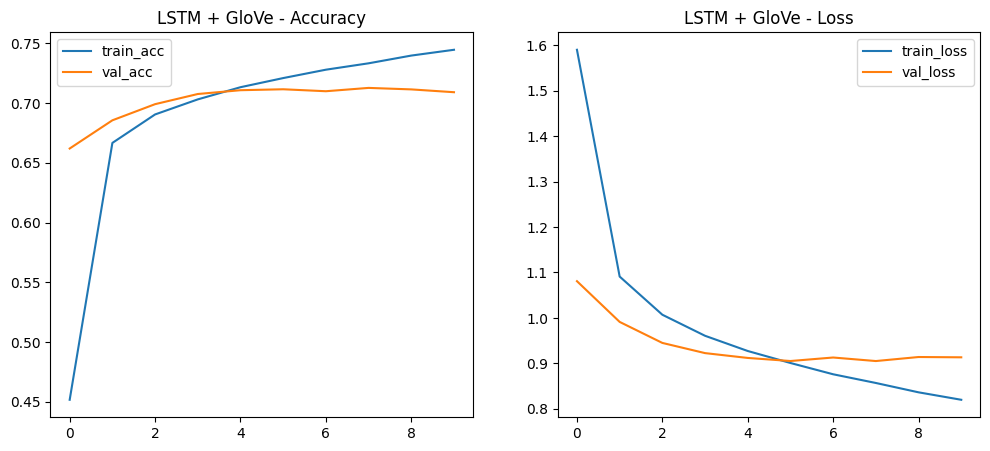

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
LSTM + GloVe — Accuracy: 0.7115, F1-score: 0.7069

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.70      0.43      0.54      6000
  Computers & Internet       0.83      0.86      0.84      6000
 Education & Reference       0.55      0.50      0.52      6000
 Entertainment & Music       0.75      0.66      0.70      6000
Family & Relationships       0.67      0.80      0.73      5999
                Health       0.74      0.81      0.77      6000
 Politics & Government       0.75      0.78      0.76      6000
 Science & Mathematics       0.69      0.79      0.74      6000
     Society & Culture       0.56      0.61      0.59      6000
                Sports       0.89      0.87      0.88      6000

              accuracy                           0.71     59999
             macro avg       0.71      0.71      0.71     59999
          weighted avg       0.71      0.71      0

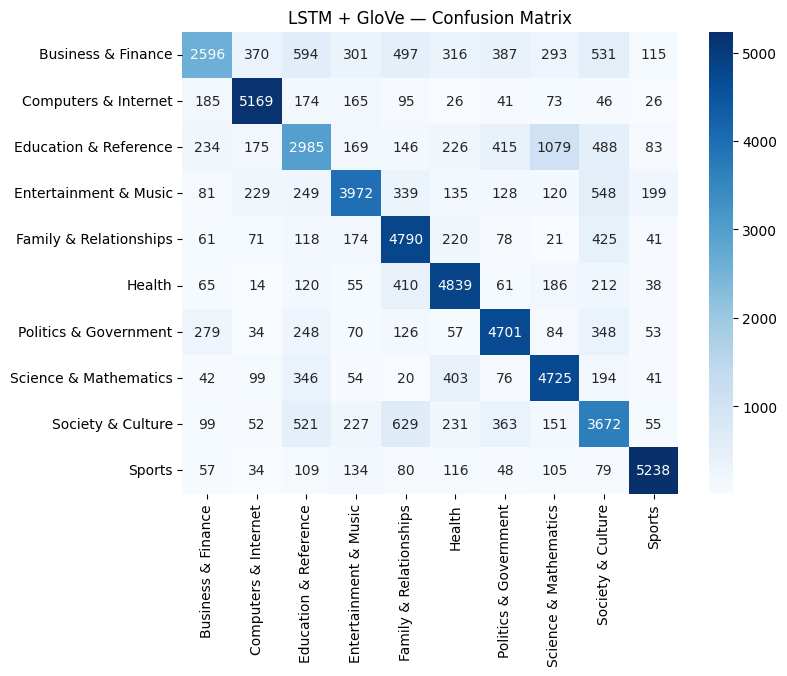

In [42]:
print("Training: LSTM + GloVe")

lstm_glove = build_model(
    rnn_type="LSTM",
    bidirectional=False,
    embedding_matrix=embedding_matrix_glove,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    trainable=False
)

history_glove = lstm_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

plot_history(history_glove, "LSTM + GloVe")
acc_glove, f1_glove = evaluate_model(lstm_glove, X_test, y_test, label_encoder, "LSTM + GloVe")

## 2. LSTM + Skip-Gram

Training: LSTM + Skip-Gram


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.2686 - loss: 1.9830 - val_accuracy: 0.6708 - val_loss: 1.0283
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.6662 - loss: 1.0867 - val_accuracy: 0.6973 - val_loss: 0.9576
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.6888 - loss: 1.0106 - val_accuracy: 0.6991 - val_loss: 0.9423
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.6968 - loss: 0.9739 - val_accuracy: 0.7063 - val_loss: 0.9144
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.7045 - loss: 0.9468 - val_accuracy: 0.7117 - val_loss: 0.8957
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7130 - loss: 0.9211 - val_accuracy: 0.7114 - val_loss: 0.8974
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7173 - loss: 0.9011 - val_accuracy: 0.7140 - val_loss: 0.8843
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7212 -

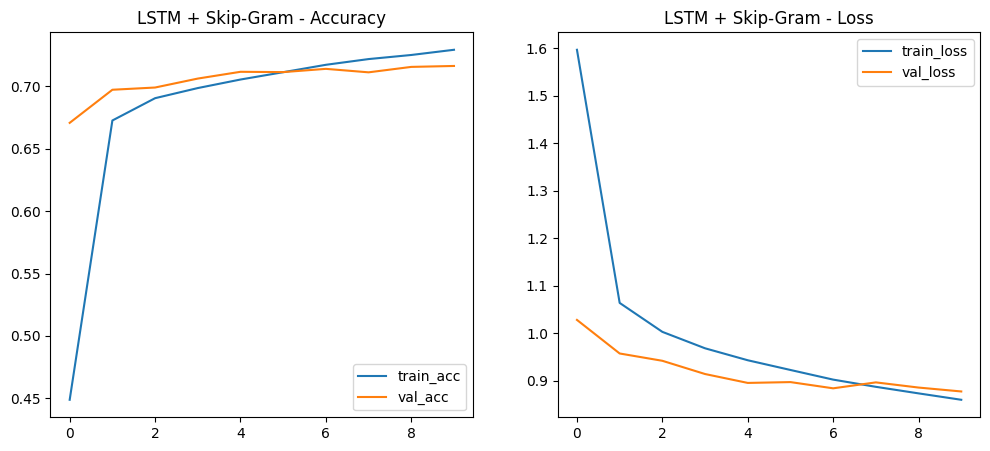

469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
LSTM + Skip-Gram — Accuracy: 0.7175, F1-score: 0.7090

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.73      0.43      0.54      6000
  Computers & Internet       0.79      0.90      0.84      6000
 Education & Reference       0.62      0.46      0.53      6000
 Entertainment & Music       0.69      0.70      0.70      6000
Family & Relationships       0.71      0.79      0.75      5999
                Health       0.75      0.81      0.78      6000
 Politics & Government       0.75      0.80      0.77      6000
 Science & Mathematics       0.69      0.79      0.74      6000
     Society & Culture       0.60      0.58      0.59      6000
                Sports       0.80      0.91      0.85      6000

              accuracy                           0.72     59999
             macro avg       0.71      0.72      0.71     59999
          weighted avg       0.71      0.72   

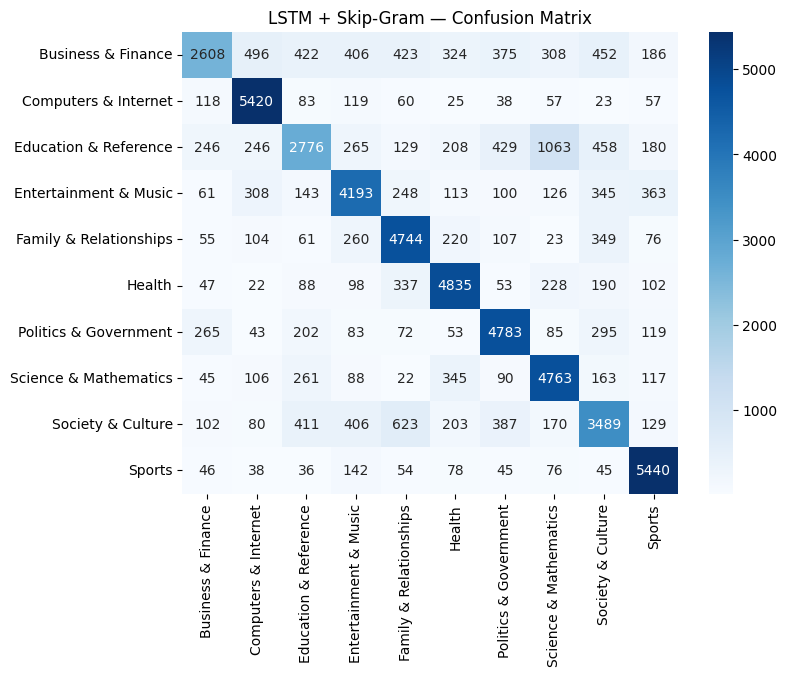

In [44]:
print("Training: LSTM + Skip-Gram")

lstm_skipgram = build_model(
    rnn_type="LSTM",
    bidirectional=False,
    embedding_matrix=embedding_matrix_skipgram,
    max_len=MAX_LEN,
    num_classes=NUM_CLASSES,
    trainable=False
)

history_skip = lstm_skipgram.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

plot_history(history_skip, "LSTM + Skip-Gram")
acc_skip, f1_skip = evaluate_model(lstm_skipgram, X_test, y_test, label_encoder, "LSTM + Skip-Gram")


# Utility To Run Multiple Models (With one go)

In [45]:
def run_experiment(rnn_type, bidirectional, emb_matrix, emb_name):
    """Helper to train + evaluate a given RNN with a chosen embedding."""
    name = f"{'Bi-' if bidirectional else ''}{rnn_type} + {emb_name}"
    print(f"\n===== Training {name} =====")

    model = build_model(
        rnn_type=rnn_type,
        bidirectional=bidirectional,
        embedding_matrix=emb_matrix,
        max_len=MAX_LEN,
        num_classes=NUM_CLASSES,
        trainable=False
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    plot_history(history, name)
    acc, f1 = evaluate_model(model, X_test, y_test, label_encoder, name)
    return name, acc, f1

## Storing the rest here

In [48]:
results = []

# Bidirectional SimpleRNN


===== Training Bi-SimpleRNN + GloVe =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10


I0000 00:00:1757414098.757321     145 service.cc:148] XLA service 0x78cbf8042950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757414098.762999     145 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757414098.763025     145 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   5/1969 ━━━━━━━━━━━━━━━━━━━━ 1:06 34ms/step - accuracy: 0.1049 - loss: 2.7941

I0000 00:00:1757414101.567817     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1969/1969 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.3467 - loss: 1.8773 - val_accuracy: 0.4348 - val_loss: 1.6559
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.4266 - loss: 1.7007 - val_accuracy: 0.4504 - val_loss: 1.6495
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.4093 - loss: 1.7254 - val_accuracy: 0.4182 - val_loss: 1.6970
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.3575 - loss: 1.8451 - val_accuracy: 0.4541 - val_loss: 1.6071
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.3024 - loss: 1.9312 - val_accuracy: 0.2916 - val_loss: 1.9055
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.2736 - loss: 1.9793 - val_accuracy: 0.2748 - val_loss: 2.0852
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.3004 - loss: 1.9630 - val_accuracy: 0.2500 - val_loss: 2.0789
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.2427 - loss: 2.07

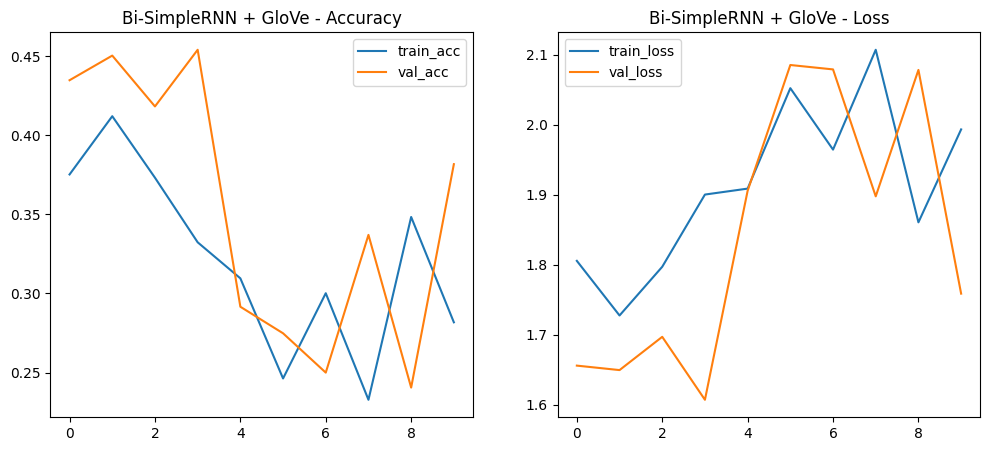

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step
Bi-SimpleRNN + GloVe — Accuracy: 0.3799, F1-score: 0.3512

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.23      0.04      0.06      6000
  Computers & Internet       0.54      0.81      0.65      6000
 Education & Reference       0.22      0.30      0.25      6000
 Entertainment & Music       0.43      0.16      0.24      6000
Family & Relationships       0.27      0.79      0.41      5999
                Health       0.40      0.47      0.43      6000
 Politics & Government       0.39      0.23      0.29      6000
 Science & Mathematics       0.41      0.28      0.33      6000
     Society & Culture       0.25      0.13      0.17      6000
                Sports       0.81      0.60      0.69      6000

              accuracy                           0.38     59999
             macro avg       0.40      0.38      0.35     59999
          weighted avg       0.40      0.

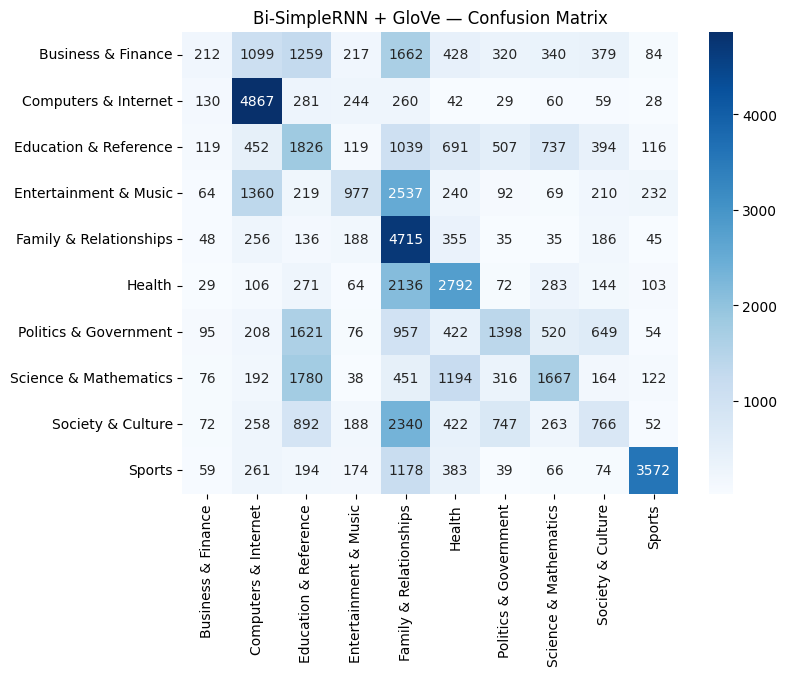


===== Training Bi-SimpleRNN + Skip-Gram =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 78s 36ms/step - accuracy: 0.4227 - loss: 1.6917 - val_accuracy: 0.6292 - val_loss: 1.1743
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.6237 - loss: 1.2246 - val_accuracy: 0.6449 - val_loss: 1.1369
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.6196 - loss: 1.2433 - val_accuracy: 0.5186 - val_loss: 1.4393
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.4001 - loss: 1.7509 - val_accuracy: 0.4279 - val_loss: 1.6800
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.4655 - loss: 1.5748 - val_accuracy: 0.5078 - val_loss: 1.5097
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.3897 - loss: 1.7600 - val_accuracy: 0.2045 - val_loss: 2.1691
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.3020 - loss: 1.9400 - val_accuracy: 0.4535 - val_loss: 1.6186
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.4470 -

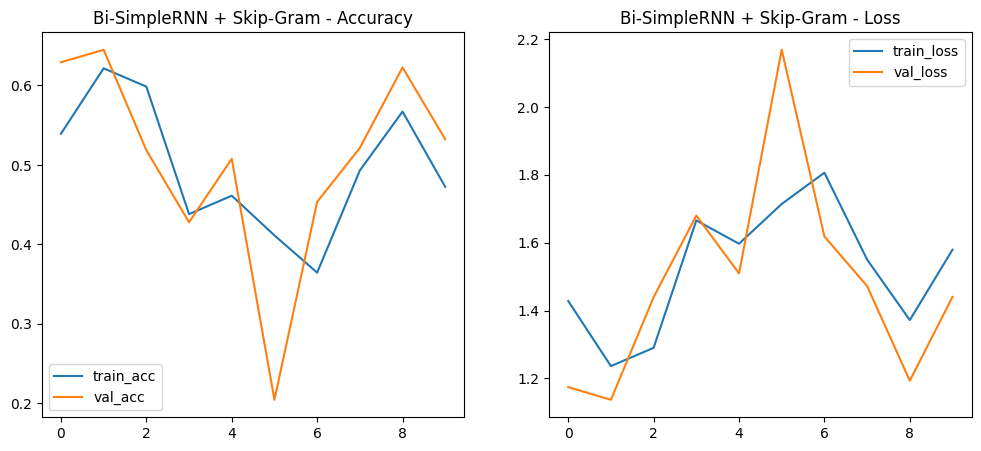

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
Bi-SimpleRNN + Skip-Gram — Accuracy: 0.5325, F1-score: 0.5136

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.35      0.31      0.33      6000
  Computers & Internet       0.68      0.86      0.76      6000
 Education & Reference       0.30      0.28      0.29      6000
 Entertainment & Music       0.48      0.24      0.32      6000
Family & Relationships       0.51      0.79      0.62      5999
                Health       0.73      0.71      0.72      6000
 Politics & Government       0.56      0.42      0.48      6000
 Science & Mathematics       0.54      0.69      0.61      6000
     Society & Culture       0.41      0.28      0.33      6000
                Sports       0.62      0.74      0.68      6000

              accuracy                           0.53     59999
             macro avg       0.52      0.53      0.51     59999
          weighted avg       0.52    

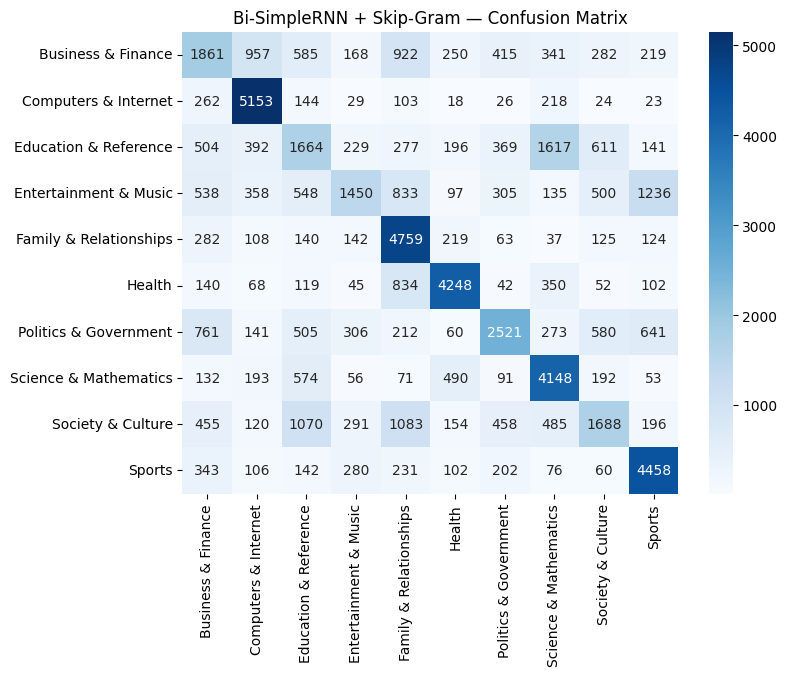

In [50]:
results.append(run_experiment("SimpleRNN", True, embedding_matrix_glove, "GloVe"))
results.append(run_experiment("SimpleRNN", True, embedding_matrix_skipgram, "Skip-Gram"))

# Bidirectional GRU


===== Training Bi-GRU + GloVe =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 73s 35ms/step - accuracy: 0.5260 - loss: 1.4093 - val_accuracy: 0.6948 - val_loss: 0.9466
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 69s 35ms/step - accuracy: 0.6900 - loss: 0.9853 - val_accuracy: 0.7056 - val_loss: 0.9108
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7035 - loss: 0.9371 - val_accuracy: 0.7094 - val_loss: 0.8995
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 69s 35ms/step - accuracy: 0.7144 - loss: 0.8980 - val_accuracy: 0.7158 - val_loss: 0.8779
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7230 - loss: 0.8737 - val_accuracy: 0.7182 - val_loss: 0.8760
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7294 - loss: 0.8483 - val_accuracy: 0.7179 - val_loss: 0.8721
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7360 - loss: 0.8239 - val_accuracy: 0.7158 - val_loss: 0.8825
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7442 -

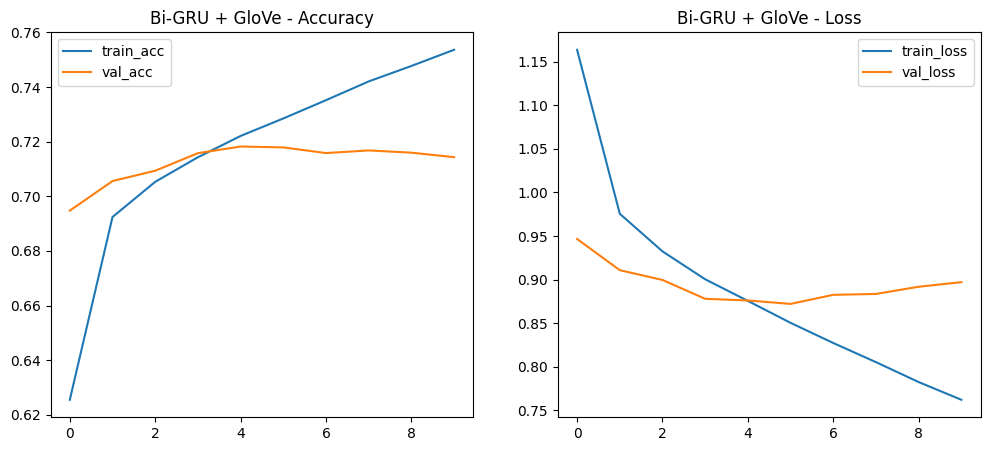

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
Bi-GRU + GloVe — Accuracy: 0.7141, F1-score: 0.7087

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.68      0.45      0.55      6000
  Computers & Internet       0.81      0.88      0.84      6000
 Education & Reference       0.57      0.52      0.54      6000
 Entertainment & Music       0.65      0.73      0.69      6000
Family & Relationships       0.65      0.82      0.73      5999
                Health       0.77      0.77      0.77      6000
 Politics & Government       0.76      0.77      0.77      6000
 Science & Mathematics       0.71      0.78      0.74      6000
     Society & Culture       0.64      0.55      0.59      6000
                Sports       0.86      0.89      0.88      6000

              accuracy                           0.71     59999
             macro avg       0.71      0.71      0.71     59999
          weighted avg       0.71      0.71    

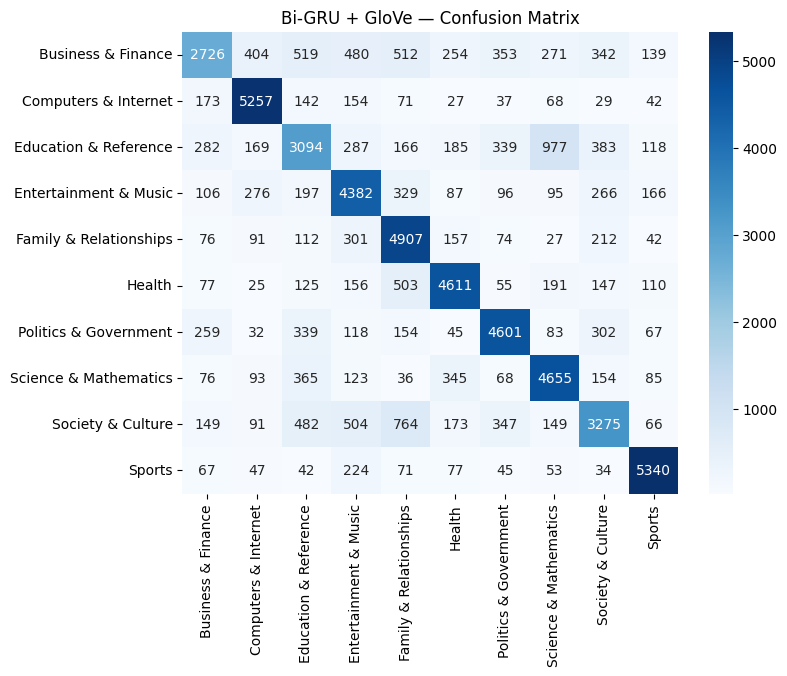


===== Training Bi-GRU + Skip-Gram =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 72s 35ms/step - accuracy: 0.5323 - loss: 1.3743 - val_accuracy: 0.7000 - val_loss: 0.9263
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.6937 - loss: 0.9703 - val_accuracy: 0.7087 - val_loss: 0.8936
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7068 - loss: 0.9258 - val_accuracy: 0.7126 - val_loss: 0.8844
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7113 - loss: 0.9045 - val_accuracy: 0.7165 - val_loss: 0.8719
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 34ms/step - accuracy: 0.7199 - loss: 0.8776 - val_accuracy: 0.7198 - val_loss: 0.8633
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7225 - loss: 0.8684 - val_accuracy: 0.7184 - val_loss: 0.8703
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7285 - loss: 0.8493 - val_accuracy: 0.7211 - val_loss: 0.8556
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.7338 -

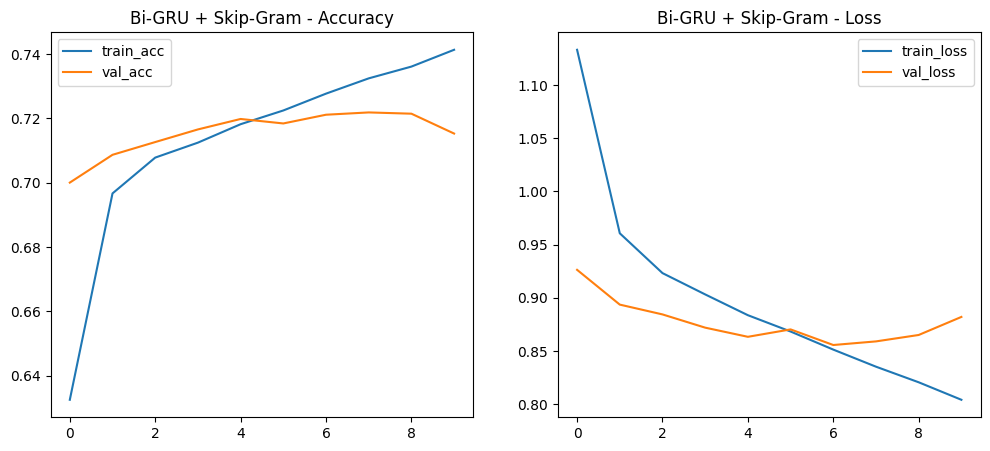

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step
Bi-GRU + Skip-Gram — Accuracy: 0.7144, F1-score: 0.7109

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.68      0.47      0.56      6000
  Computers & Internet       0.84      0.87      0.86      6000
 Education & Reference       0.60      0.48      0.54      6000
 Entertainment & Music       0.67      0.72      0.69      6000
Family & Relationships       0.73      0.76      0.75      5999
                Health       0.76      0.81      0.79      6000
 Politics & Government       0.71      0.82      0.76      6000
 Science & Mathematics       0.70      0.77      0.73      6000
     Society & Culture       0.56      0.64      0.60      6000
                Sports       0.90      0.79      0.84      6000

              accuracy                           0.71     59999
             macro avg       0.72      0.71      0.71     59999
          weighted avg       0.72      0.71

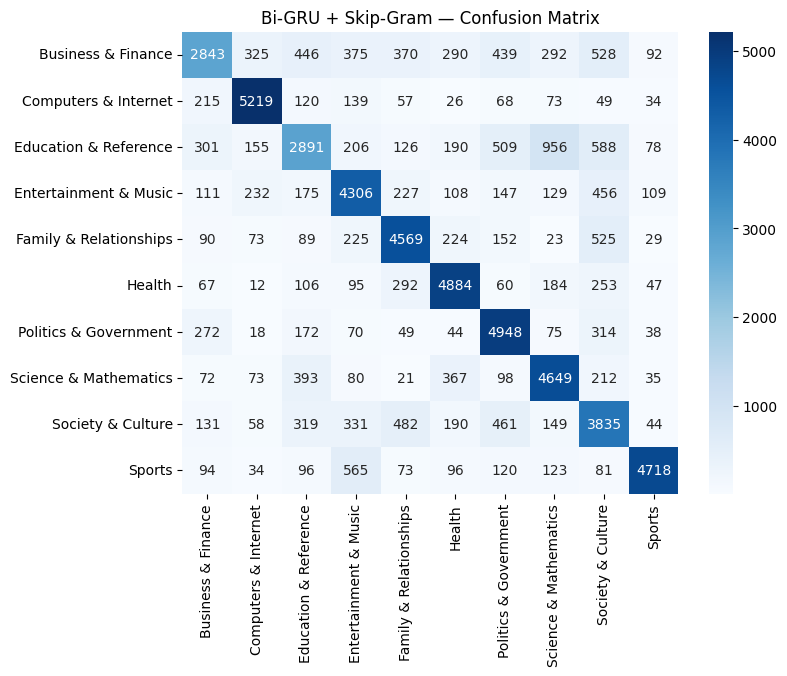

In [51]:
results.append(run_experiment("GRU", True, embedding_matrix_glove, "GloVe"))
results.append(run_experiment("GRU", True, embedding_matrix_skipgram, "Skip-Gram"))

# Bidirectional LSTM


===== Training Bi-LSTM + GloVe =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.5687 - loss: 1.3199 - val_accuracy: 0.6944 - val_loss: 0.9517
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.6887 - loss: 0.9836 - val_accuracy: 0.7001 - val_loss: 0.9232
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7045 - loss: 0.9328 - val_accuracy: 0.7105 - val_loss: 0.8937
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7128 - loss: 0.9037 - val_accuracy: 0.7137 - val_loss: 0.8880
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7220 - loss: 0.8739 - val_accuracy: 0.7159 - val_loss: 0.8795
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7287 - loss: 0.8506 - val_accuracy: 0.7152 - val_loss: 0.8850
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7350 - loss: 0.8288 - val_accuracy: 0.7179 - val_loss: 0.8816
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7407 -

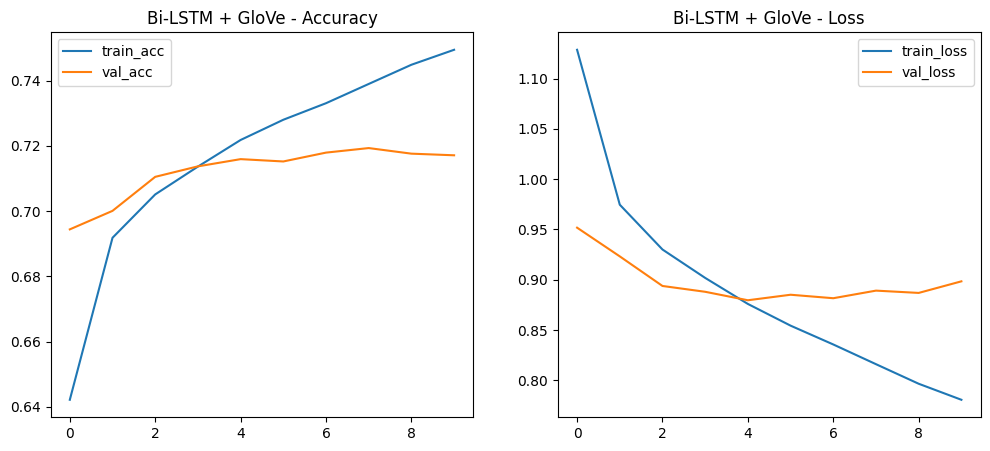

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
Bi-LSTM + GloVe — Accuracy: 0.7181, F1-score: 0.7126

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.68      0.45      0.54      6000
  Computers & Internet       0.83      0.85      0.84      6000
 Education & Reference       0.58      0.50      0.54      6000
 Entertainment & Music       0.68      0.72      0.70      6000
Family & Relationships       0.69      0.80      0.74      5999
                Health       0.75      0.81      0.78      6000
 Politics & Government       0.75      0.79      0.77      6000
 Science & Mathematics       0.68      0.81      0.74      6000
     Society & Culture       0.62      0.57      0.60      6000
                Sports       0.88      0.88      0.88      6000

              accuracy                           0.72     59999
             macro avg       0.71      0.72      0.71     59999
          weighted avg       0.71      0.72   

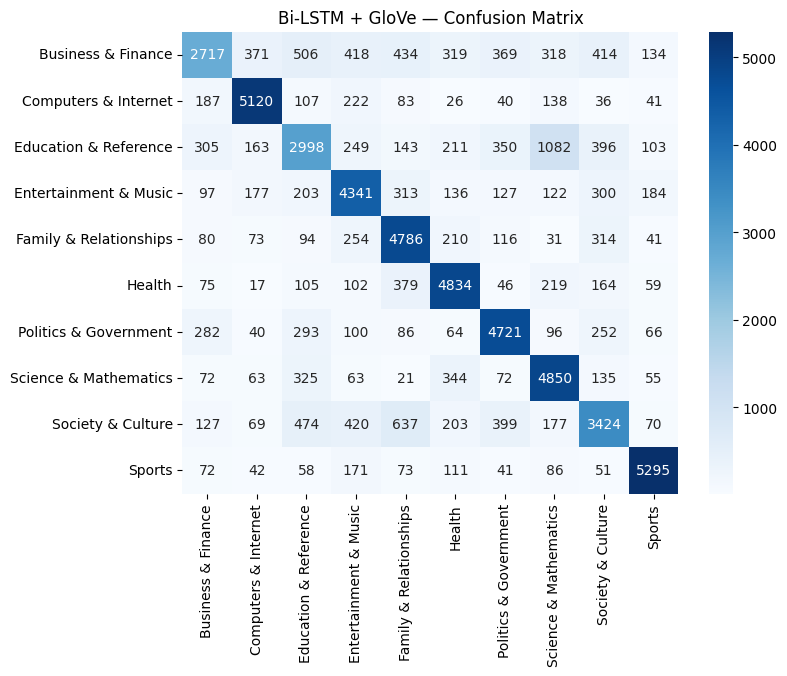


===== Training Bi-LSTM + Skip-Gram =====


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.5703 - loss: 1.3029 - val_accuracy: 0.6957 - val_loss: 0.9423
Epoch 2/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.6928 - loss: 0.9738 - val_accuracy: 0.7057 - val_loss: 0.9130
Epoch 3/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7059 - loss: 0.9321 - val_accuracy: 0.7133 - val_loss: 0.8870
Epoch 4/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7098 - loss: 0.9107 - val_accuracy: 0.7145 - val_loss: 0.8828
Epoch 5/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7178 - loss: 0.8896 - val_accuracy: 0.7174 - val_loss: 0.8742
Epoch 6/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7216 - loss: 0.8720 - val_accuracy: 0.7205 - val_loss: 0.8677
Epoch 7/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 76s 39ms/step - accuracy: 0.7268 - loss: 0.8528 - val_accuracy: 0.7221 - val_loss: 0.8586
Epoch 8/10
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 77s 39ms/step - accuracy: 0.7306 -

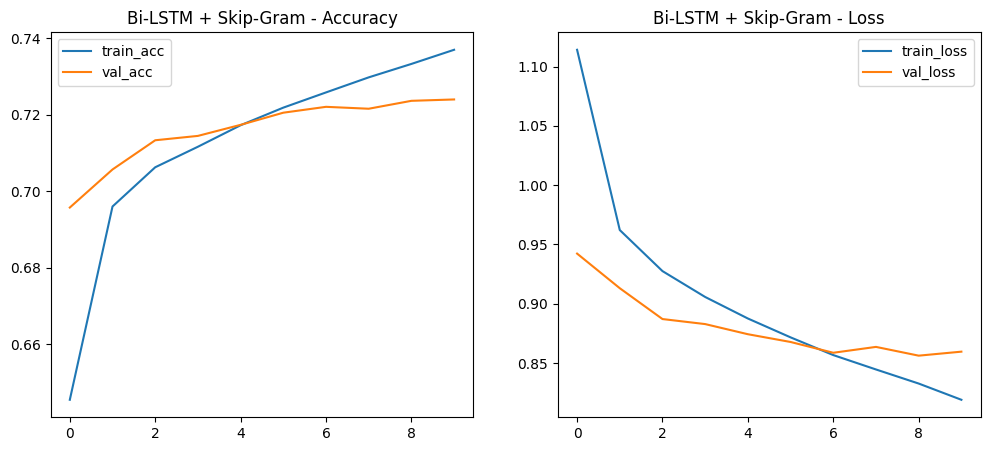

469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step
Bi-LSTM + Skip-Gram — Accuracy: 0.7230, F1-score: 0.7176

Classification Report:
                         precision    recall  f1-score   support

    Business & Finance       0.66      0.48      0.56      6000
  Computers & Internet       0.82      0.89      0.85      6000
 Education & Reference       0.59      0.51      0.55      6000
 Entertainment & Music       0.65      0.77      0.70      6000
Family & Relationships       0.70      0.79      0.74      5999
                Health       0.76      0.81      0.78      6000
 Politics & Government       0.78      0.78      0.78      6000
 Science & Mathematics       0.70      0.78      0.74      6000
     Society & Culture       0.65      0.54      0.59      6000
                Sports       0.88      0.88      0.88      6000

              accuracy                           0.72     59999
             macro avg       0.72      0.72      0.72     59999
          weighted avg       0.72      0.7

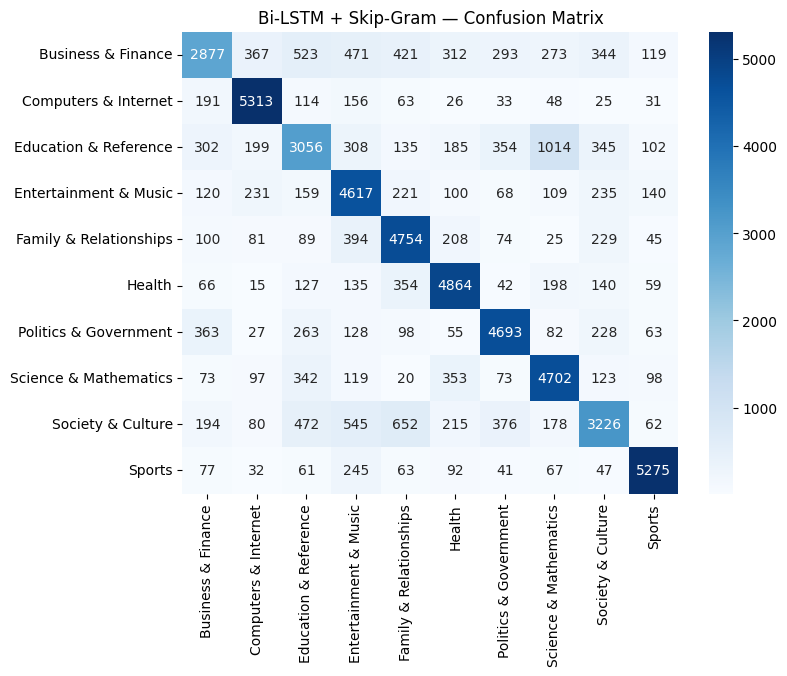

In [52]:
results.append(run_experiment("LSTM", True, embedding_matrix_glove, "GloVe"))
results.append(run_experiment("LSTM", True, embedding_matrix_skipgram, "Skip-Gram"))

# DNN (dense feed-forward)

## DNN GloVe

In [ ]:
dnn_glove = build_model(
    embedding_matrix=embedding_matrix_glove,
    model_type="DNN"
)

history_dnn_glove = dnn_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# evaluate_model(dnn_glove, history_dnn_glove, "DNN (GloVe)", X_test, y_test, label_encoder)

evaluate_model(
    dnn_glove, 
    X_test, 
    y_test, 
    class_names=label_encoder.classes_, 
    model_name="DNN_GloVe"
)


## DNN Skip-Gram

In [ ]:
dnn_skip = build_model(
    embedding_matrix=embedding_matrix_skipgram,
    model_type="DNN"
)
history_dnn_skip = dnn_skip.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
evaluate_model(dnn_skip, history_dnn_skip, "DNN (Skip-gram)", X_test, y_test, label_encoder)

# SimpleRNN

## SimpleRNN (GloVe)

In [ ]:
rnn_glove = build_model(
    embedding_matrix=embedding_matrix_glove,
    model_type="SimpleRNN"
)
history_rnn_glove = rnn_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
evaluate_model(rnn_glove, history_rnn_glove, "SimpleRNN (GloVe)", X_test, y_test, label_encoder)

## SimpleRNN (Skip-Gram)

In [ ]:
rnn_skip = build_model(
    embedding_matrix=embedding_matrix_skipgram,
    model_type="SimpleRNN"
)
history_rnn_skip = rnn_skip.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
evaluate_model(rnn_skip, history_rnn_skip, "SimpleRNN (Skip-gram)", X_test, y_test, label_encoder)

# GRU

## GRU (GloVe)

In [ ]:
gru_glove = build_model(
    embedding_matrix=embedding_matrix_glove,
    model_type="GRU"
)
history_gru_glove = gru_glove.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
evaluate_model(gru_glove, history_gru_glove, "GRU (GloVe)", X_test, y_test, label_encoder)

## GRU (Skip-Gram)

In [ ]:
gru_skip = build_model(
    embedding_matrix=embedding_matrix_skipgram,
    model_type="GRU"
)
history_gru_skip = gru_skip.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
evaluate_model(gru_skip, history_gru_skip, "GRU (Skip-gram)", X_test, y_test, label_encoder)